# Notebook 2 — Feature Engineering

Objectif : créer de nouvelles variables à partir des données brutes pour enrichir le pouvoir prédictif des modèles.

**Outils :** Pandas (manipulation) · NumPy (calculs)

**Source :** `dataset_clean.csv` (issu du notebook 1)

---
### Pourquoi faire du feature engineering ?
Les modèles apprennent mieux sur des variables qui **capturent directement** le phénomène d'intérêt. Par exemple, un *ratio temps d'écran / sommeil* peut être plus expressif que les deux variables séparées.

In [1]:
# import os, sys

# # Sur Google Colab : upload automatique de dataset_clean.csv s'il est absent
# if 'google.colab' in sys.modules or os.path.exists('/content'):
#     if not os.path.exists('dataset_clean.csv'):
#         from google.colab import files
#         print("Fichier manquant — sélectionnez dataset_clean.csv à uploader.")
#         files.upload()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('dataset_clean.csv')
print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head(3)

Dataset chargé : 15,000 lignes × 15 colonnes


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,screen_time_bin,age_group
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57,2-4h,>55 ans
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,297,1.91,< 2h,46-55 ans
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,22,6.05,2-4h,26-35 ans


## 1. Variables de ratio

Les ratios capturent des **relations proportionnelles** entre deux variables. Ils sont souvent plus stables que les valeurs brutes.

In [3]:
# Ratio temps d'écran / durée du sommeil
# Plus ce ratio est élevé, plus l'écran 'prend' de place par rapport au sommeil
df['screen_to_sleep_ratio'] = (
    df['daily_screen_time_hours'] / df['sleep_duration_hours'].replace(0, np.nan)
).round(4)

# Part du temps pré-sommeil consacrée au téléphone (en % de la durée totale de sommeil)
df['pre_sleep_phone_pct'] = (
    df['phone_usage_before_sleep_minutes'] / (df['sleep_duration_hours'] * 60) * 100
).round(2)

# Densité de notifications par heure d'écran
df['notif_per_screen_hour'] = (
    df['notifications_received_per_day'] / df['daily_screen_time_hours'].replace(0, np.nan)
).round(2)

print('Nouvelles variables de ratio créées :')
df[['screen_to_sleep_ratio', 'pre_sleep_phone_pct', 'notif_per_screen_hour']].describe().round(3)

Nouvelles variables de ratio créées :


,screen_to_sleep_ratio,pre_sleep_phone_pct,notif_per_screen_hour
count,15000.000,15000.000,15000.000
mean,0.892,16.144,41.041
std,0.483,10.372,38.856
min,0.122,0.190,2.250
25%,0.501,7.580,16.430
50%,0.845,15.330,29.140
75%,1.199,23.080,50.350
max,2.449,48.560,272.480


## 2. Indices composites

On agrège plusieurs variables pour créer des **indicateurs synthétiques** reflétant un concept global (charge numérique, bien-être, etc.).

In [4]:
# Charge numérique totale : écran journalier + téléphone avant sommeil (converti en heures)
df['digital_load_hours'] = (
    df['daily_screen_time_hours'] + df['phone_usage_before_sleep_minutes'] / 60
).round(3)

# Indice stress-fatigue : moyenne du stress et de la fatigue mentale
df['stress_fatigue_index'] = (
    (df['stress_level'] + df['mental_fatigue_score']) / 2
).round(3)

# Score de bien-être global : qualité sommeil + activité physique normalisée - stress
# On normalise l'activité physique (max ~60 min/jour = 1h)
df['wellness_score'] = (
    df['sleep_quality_score']
    + df['physical_activity_minutes'] / 60
    - df['stress_level']
).round(3)

# Déficit de sommeil par rapport à la norme de 8h
df['sleep_deficit_hours'] = (8 - df['sleep_duration_hours']).clip(lower=0).round(3)

print('Indices composites créés :')
df[['digital_load_hours', 'stress_fatigue_index', 'wellness_score', 'sleep_deficit_hours']].describe().round(3)

Indices composites créés :


,digital_load_hours,stress_fatigue_index,wellness_score,sleep_deficit_hours
count,15000.000,15000.000,15000.000,15000.000
mean,6.497,6.927,0.252,1.594
std,2.664,2.705,4.343,1.311
min,1.107,1.000,-8.700,0.000
25%,4.229,4.740,-3.574,0.210
50%,6.487,7.390,-0.142,1.510
75%,8.754,9.545,3.698,2.740
max,11.887,10.000,10.967,3.950


## 3. Variables binaires (flags)

Ces variables booléennes catégorisent les individus selon des **seuils métier** reconnus.

In [5]:
# Utilisateur intensif : plus de 6h d'écran/jour
df['is_heavy_user'] = (df['daily_screen_time_hours'] > 6).astype(int)

# Utilisateur du téléphone avant de dormir : > 30 min
df['phone_before_sleep_flag'] = (df['phone_usage_before_sleep_minutes'] > 30).astype(int)

# Dormeur court : moins de 6h de sommeil (seuil OMS)
df['short_sleeper'] = (df['sleep_duration_hours'] < 6).astype(int)

# Stress élevé : niveau > 7 (sur 10)
df['high_stress_flag'] = (df['stress_level'] > 7).astype(int)

# Sédentaire : moins de 30 min d'activité physique
df['sedentary_flag'] = (df['physical_activity_minutes'] < 30).astype(int)

flags = ['is_heavy_user', 'phone_before_sleep_flag', 'short_sleeper', 'high_stress_flag', 'sedentary_flag']
print('Répartition des variables binaires (% de 1) :')
for f in flags:
    pct = df[f].mean() * 100
    print(f'  {f:<30} : {pct:.1f}%')

Répartition des variables binaires (% de 1) :
  is_heavy_user                  : 44.1%
  phone_before_sleep_flag        : 74.2%
  short_sleeper                  : 40.1%
  high_stress_flag               : 53.8%
  sedentary_flag                 : 25.4%


## 4. Transformations mathématiques

Certaines variables ont une distribution asymétrique (skewed). Une **transformation logarithmique** les rapproche de la normalité, ce qui améliore les modèles linéaires.

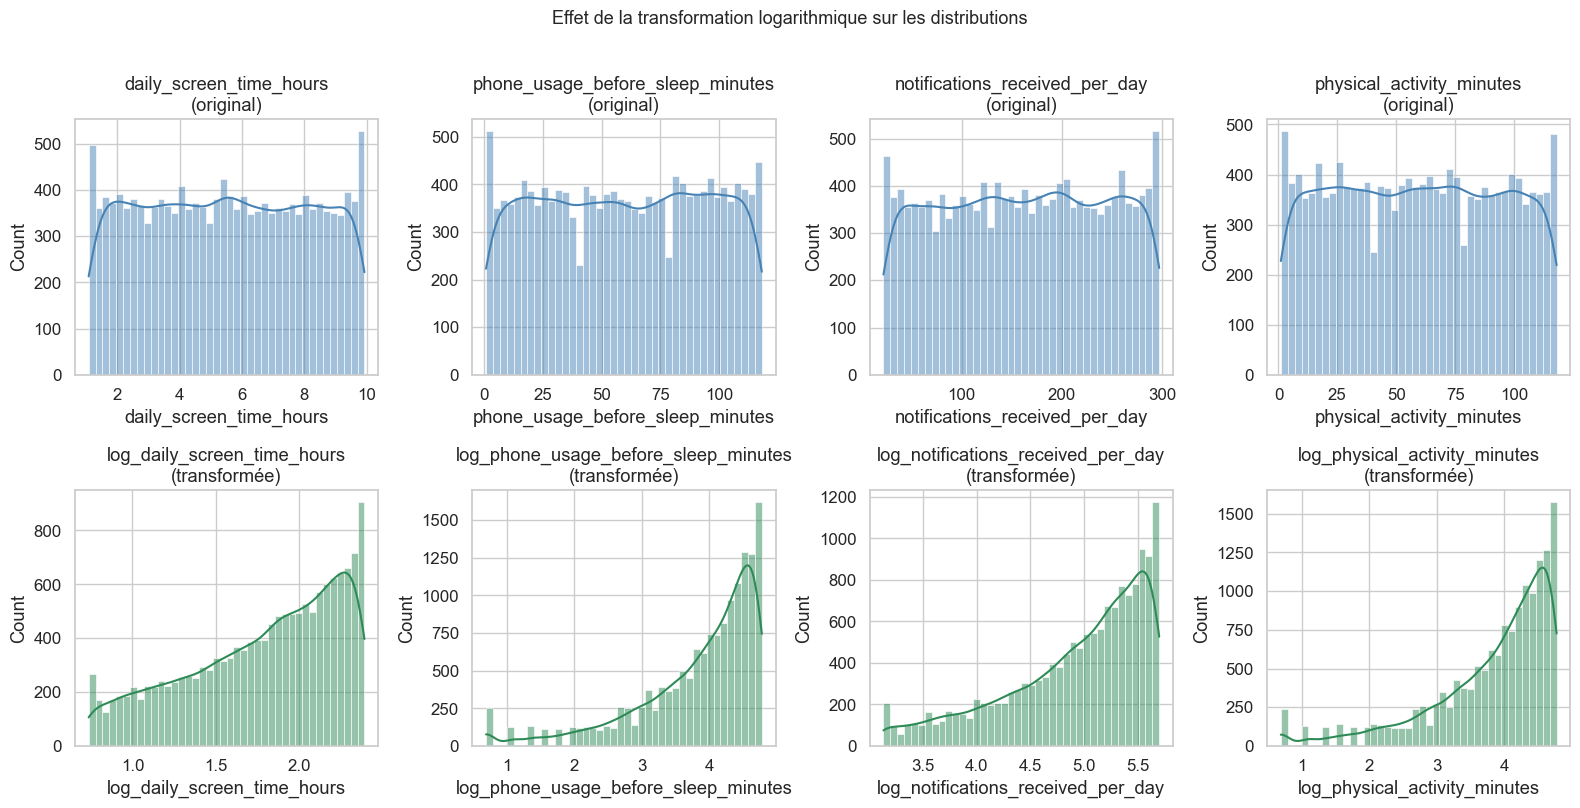

In [6]:
# Transformation log1p (log(1+x)) pour éviter log(0)
vars_to_log = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'notifications_received_per_day',
    'physical_activity_minutes',
]

for var in vars_to_log:
    df[f'log_{var}'] = np.log1p(df[var]).round(4)

# Visualisation : avant / après transformation log
fig, axes = plt.subplots(2, len(vars_to_log), figsize=(16, 8))
for i, var in enumerate(vars_to_log):
    sns.histplot(df[var],            kde=True, ax=axes[0][i], color='steelblue', bins=40)
    sns.histplot(df[f'log_{var}'],   kde=True, ax=axes[1][i], color='seagreen',  bins=40)
    axes[0][i].set_title(f'{var}\n(original)')
    axes[1][i].set_title(f'log_{var}\n(transformée)')
plt.suptitle('Effet de la transformation logarithmique sur les distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Variables d'interaction

Une **variable d'interaction** est le produit de deux variables. Elle capture l'effet *combiné* qui ne serait pas détecté séparément.

In [7]:
# Interaction : temps d'écran × caféine (double stimulation numérique + chimique)
df['screen_x_caffeine'] = (df['daily_screen_time_hours'] * df['caffeine_intake_cups']).round(3)

# Interaction : téléphone avant sommeil × stress (perturbation nocturne amplifiée par le stress)
df['presleep_x_stress'] = (df['phone_usage_before_sleep_minutes'] * df['stress_level']).round(3)

# Interaction : activité physique × qualité du sommeil (cercle vertueux)
df['activity_x_sleep_quality'] = (df['physical_activity_minutes'] * df['sleep_quality_score']).round(3)

print('Corrélations des variables d\'interaction avec sleep_duration_hours :')
interactions = ['screen_x_caffeine', 'presleep_x_stress', 'activity_x_sleep_quality']
for col in interactions:
    r = df[col].corr(df['sleep_duration_hours'])
    print(f'  {col:<40} r = {r:+.4f}')

Corrélations des variables d'interaction avec sleep_duration_hours :
  screen_x_caffeine                        r = -0.0039
  presleep_x_stress                        r = -0.0100
  activity_x_sleep_quality                 r = +0.0040


## 6. Features polynomiales

On ajoute le carré des variables principales pour capturer des **relations non linéaires** (ex : l'effet du temps d'écran sur le sommeil n'est peut-être pas linéaire).

In [8]:
# Termes quadratiques pour les variables explicatives principales
df['screen_time_sq'] = (df['daily_screen_time_hours'] ** 2).round(4)
df['presleep_phone_sq'] = (df['phone_usage_before_sleep_minutes'] ** 2).round(4)
df['notifications_sq'] = (df['notifications_received_per_day'] ** 2).round(4)

# Comparaison corrélation linéaire vs quadratique avec sleep_duration_hours
print('Corrélations linéaires vs quadratiques avec sleep_duration_hours :')
comps = [
    ('daily_screen_time_hours', 'screen_time_sq'),
    ('phone_usage_before_sleep_minutes', 'presleep_phone_sq'),
    ('notifications_received_per_day', 'notifications_sq'),
]
for linear, quad in comps:
    r_lin = df[linear].corr(df['sleep_duration_hours'])
    r_quad = df[quad].corr(df['sleep_duration_hours'])
    print(f'  {linear:<40} linéaire: {r_lin:+.4f}  quadratique: {r_quad:+.4f}')

Corrélations linéaires vs quadratiques avec sleep_duration_hours :
  daily_screen_time_hours                  linéaire: -0.0019  quadratique: -0.0029
  phone_usage_before_sleep_minutes         linéaire: -0.0129  quadratique: -0.0128
  notifications_received_per_day           linéaire: +0.0054  quadratique: +0.0038


## 7. Encodage des variables catégorielles

Les modèles ML ne traitent pas le texte directement. On encode les variables catégorielles en valeurs numériques.

In [9]:
# Encodage binaire du genre (1 = Female, 0 = Male, NaN pour Other si présent)
df['gender_encoded'] = df['gender'].map({'Female': 1, 'Male': 0})

# One-Hot Encoding de la profession (get_dummies crée autant de colonnes que de modalités)
occupation_dummies = pd.get_dummies(df['occupation'], prefix='occ', drop_first=True)
df = pd.concat([df, occupation_dummies], axis=1)

print(f'Colonnes créées par le One-Hot Encoding de occupation :')
print([c for c in df.columns if c.startswith('occ_')])

Colonnes créées par le One-Hot Encoding de occupation :
['occ_Doctor', 'occ_Freelancer', 'occ_Manager', 'occ_Researcher', 'occ_Software Engineer', 'occ_Student', 'occ_Teacher']


## 8. Bilan et export

In [12]:
nouvelles_vars = [
    'screen_to_sleep_ratio', 'pre_sleep_phone_pct', 'notif_per_screen_hour',
    'digital_load_hours', 'stress_fatigue_index', 'wellness_score', 'sleep_deficit_hours',
    'is_heavy_user', 'phone_before_sleep_flag', 'short_sleeper', 'high_stress_flag', 'sedentary_flag',
    'screen_x_caffeine', 'presleep_x_stress', 'activity_x_sleep_quality',
    'screen_time_sq', 'presleep_phone_sq', 'notifications_sq',
    'gender_encoded',
] + [c for c in df.columns if c.startswith('log_')] + [c for c in df.columns if c.startswith('occ_')]

print(f'Dataset original  : {df.shape[1] - len(nouvelles_vars)} colonnes')
print(f'Nouvelles features : {len(nouvelles_vars)}')
print(f'Dataset final      : {df.shape[1]} colonnes × {df.shape[0]:,} lignes')

df.to_csv('dataset_engineered.csv', index=False)
print('\n Exporté : dataset_engineered.csv')

Dataset original  : 15 colonnes
Nouvelles features : 30
Dataset final      : 45 colonnes × 15,000 lignes

 Exporté : dataset_engineered.csv


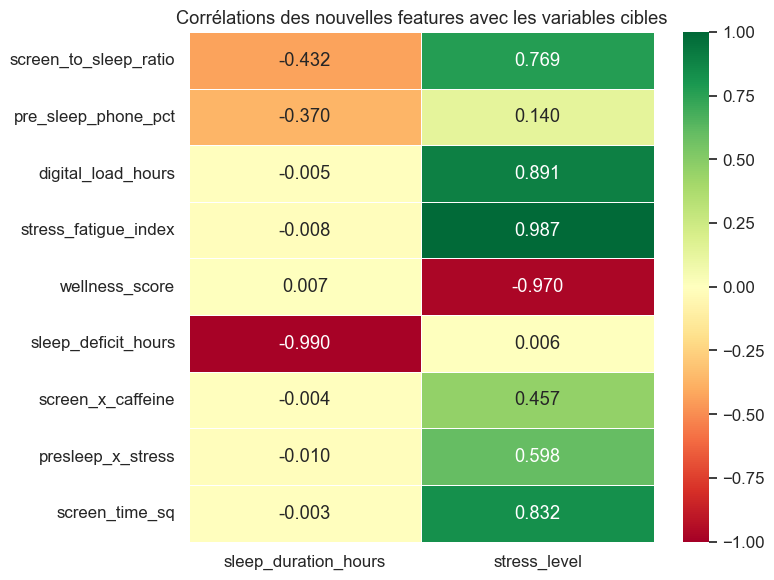

In [11]:
# Heatmap de corrélation des nouvelles features avec les variables cibles
targets = ['sleep_duration_hours', 'stress_level']
new_num_vars = [
    'screen_to_sleep_ratio', 'pre_sleep_phone_pct', 'digital_load_hours',
    'stress_fatigue_index', 'wellness_score', 'sleep_deficit_hours',
    'screen_x_caffeine', 'presleep_x_stress', 'screen_time_sq'
]

corr_new = df[new_num_vars + targets].corr()[targets].drop(targets)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_new, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Corrélations des nouvelles features avec les variables cibles')
plt.tight_layout()
plt.show()